<a href="https://colab.research.google.com/github/AarushMuthukrishnan/Machine-Learning-Notebooks/blob/main/Early_Wakeup_Health_%26_Lifestyle_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early Wakeup Health & Lifestyle Dataset - Exploratory Data Analysis

In this Exploratory Data Analysis, we will be looking at the Early Wakeup Health & Lifestyle Dataset found on Kaggle, studying the dataset and it's different characteristics.

Let's import the necessary modules:

In [ ]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import int64, float64

Let's start off by importing the dataset from Kaggle into our environment:

In [ ]:


# Download latest version
path = kagglehub.dataset_download("nalisha/early-wakeup-health-and-lifestyle-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'early-wakeup-health-and-lifestyle-dataset' dataset.
Path to dataset files: /kaggle/input/early-wakeup-health-and-lifestyle-dataset


Now, let's import the **Pandas** library, read in the CSV file, and store the **DataFrame** object into a variable named **data**:

In [ ]:
data = pd.read_csv("/kaggle/input/early-wakeup-health-and-lifestyle-dataset/early_wakeup_health_dataset.csv")

Now that we have the dataset set up, let's first take a glance of how it looks from a highlevel. Let's see how the dataset is structured from the first few rows:

In [ ]:
data.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No


Let's look at one of the columns that have numerical values, such as **Age**:

In [ ]:
data.Age.describe()

,Age
count,10000.0000
mean,44.6667
std,17.5172
min,18.0000
25%,29.7500
50%,43.0000
75%,58.0000
max,80.0000


From this, we can see that in this dataset, a variety of ages were surveyed, ranging from 18 to 80, with the average person being around 44 years old.

We can see that there are quite the amount of columns, but let's identify the potential features and target variables for this dataset. Let's look at each column:

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  object 
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  object 
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  object 
 7   Occupation                      10000 non-null  object 
 8   Marital_Status                  10000 non-null  object 
 9   Wake_Up_Time                    10000 non-null  object 
 10  Sleep_Time                      10000 non-null  object 
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

From this, we can identify 2 things:


1.   42 of the columns consist of numbers, while 22 are of type **object**


*   28 of the columns consist of some sort of decimal, while the rest of the 14 are just integers


2.   The columns, "Exercise_Type", "Workout_Intensity", and "Alcohol_Consumption" all appear to have missing or **null** values.  

Let's focus on the second observation. We can consider these as the target variables, with the rest of the columns being features. We now have identified the specific targets a model in the future could predict.



But first, let's handle those missing values by simply filling them with 0:

In [ ]:
data = data.fillna(0)

We can now see all columns are now updated and filled:

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  object 
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  object 
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  object 
 7   Occupation                      10000 non-null  object 
 8   Marital_Status                  10000 non-null  object 
 9   Wake_Up_Time                    10000 non-null  object 
 10  Sleep_Time                      10000 non-null  object 
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

Previously, we identified different targets a model could be predicting, but in reality the model could try and predict any one of these columns as a target. To further easily model and visualize the dataset, let's filter out all columns that aren't numerical values:

In [ ]:
dataNum = data[data.dtypes[(data.dtypes == int64) | (data.dtypes == float64)].index.tolist()]
dataNum

,Age,Height_cm,Weight_kg,BMI,Sleep_Duration_Hours,Sleep_Quality_Score,Number_of_Night_Awakenings,Weekend_Sleep_Difference_Hours,Nap_Frequency_Per_Week,Screen_Time_Before_Bed_Hours,...,Fatigue_Level_Score,Immune_Health_Score,Mood_Score,Anxiety_Score,Depression_Risk_Score,Productivity_Score,Focus_Concentration_Score,Life_Satisfaction_Score,Health_Score,Healthy_Aging_Score
0,76,158.8,62.1,24.63,7.51,5.9,2,1.28,5,1.65,...,2.0,7.0,8.1,4.0,1.7,6.2,7.4,8.0,87.3,81.8
1,49,160.9,68.5,26.45,4.16,5.5,0,0.24,1,1.63,...,1.0,4.1,7.7,5.8,1.5,8.2,5.5,9.3,72.0,75.2
2,51,151.9,54.8,23.77,5.12,8.4,0,1.54,4,0.04,...,2.8,5.9,6.5,5.7,1.5,7.6,6.6,7.1,75.2,77.1
3,48,167.6,81.3,28.93,7.29,4.6,1,0.37,1,2.56,...,2.6,9.5,6.3,5.4,1.7,7.9,6.5,8.6,82.7,87.1
4,68,171.9,75.4,25.51,5.79,6.1,1,1.81,2,1.18,...,3.6,7.8,4.4,6.6,3.1,4.4,6.1,6.7,62.7,58.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,66,170.2,86.4,29.84,7.13,5.7,0,-0.73,2,0.54,...,1.0,7.8,6.4,5.1,1.0,7.5,7.3,6.2,67.8,53.8
9996,70,182.3,86.9,26.14,8.07,7.7,1,0.32,3,1.41,...,3.7,6.7,7.6,5.4,1.2,7.8,7.7,7.8,84.8,78.5
9997,29,170.4,81.2,27.96,7.98,3.7,1,0.77,0,1.25,...,7.1,5.7,4.2,6.4,4.1,4.7,4.9,6.3,54.2,59.2
9998,22,186.5,78.3,22.52,4.90,5.3,0,0.61,5,1.35,...,4.2,5.5,7.9,5.9,1.0,6.8,5.7,8.6,78.9,84.2


Before we continue, we must first perform more feature engineering to our current dataset. Let's first skew the variables with a threshold about 0.75:

In [ ]:
skew_cols = (dataNum.skew()
             .sort_values(ascending=False)
             .to_frame()
             .rename(columns={0:'Skew'})
             .query('abs(Skew) > {}'.format(0.75)))

skew_cols

,Skew
Screen_Time_Before_Bed_Hours,1.190599
Depression_Risk_Score,1.174052
Number_of_Night_Awakenings,1.121856
Outdoor_Time_Hours,1.010463
Sugary_Drinks_Per_Week,0.834720
Nap_Frequency_Per_Week,0.765930


Let's now apply log transform on one of our features, such as **Screen_Time_Before_Bed_Hours**:

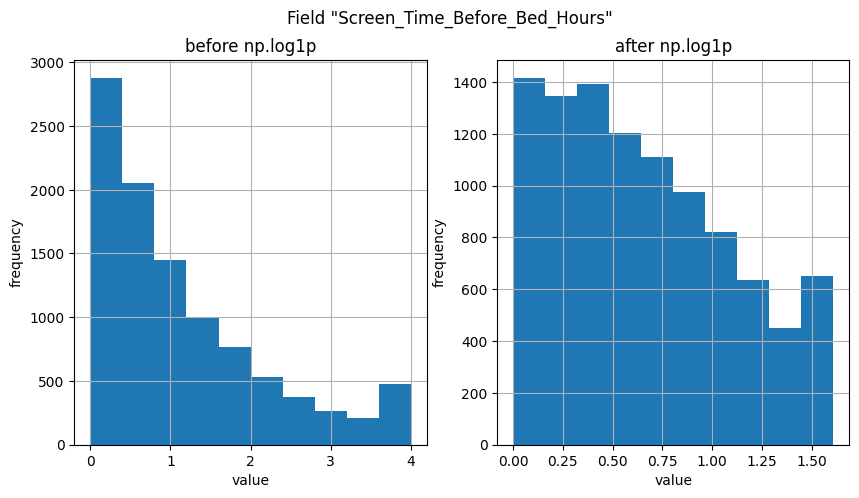

In [ ]:
field = "Screen_Time_Before_Bed_Hours"

fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(10, 5))

data[field].hist(ax=ax_before)

data[field].apply(np.log1p).hist(ax=ax_after)

ax_before.set(title='before np.log1p', ylabel='frequency', xlabel='value')
ax_after.set(title='after np.log1p', ylabel='frequency', xlabel='value')
fig.suptitle('Field "{}"'.format(field));

Let's now consider these 3 hypothesis:


1.   A person's age correlates with their exercise type
2.   A person's age correlates with their workout intensity
3.   A person's age correlates with their healthy aging



Let's test out the third one by creating a scatter plot between these 2 data points:

<Axes: xlabel='Age', ylabel='Healthy_Aging_Score'>

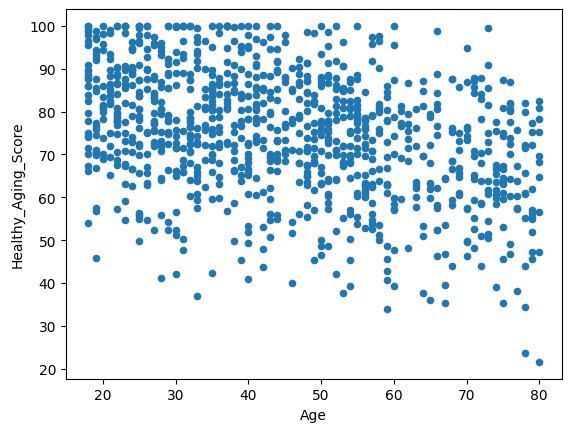

In [ ]:
dataNum.loc[:1000].plot.scatter(x="Age", y="Healthy_Aging_Score")

As we can see, there tends to be a negative correlation between age and healthy aging score, so it's safe to assume our hypothesis was correct.

Let's sum up what we explored. This dataset can be extremely usefull to find out and predict different metrics of a human, especially their sleep and daily habit patterns, from different characteristics such as your age and weight. The dataset contains a variety of features ranging from numerical to strings, with all but 3 columns without missing values. It was important, however, to scale the values so they can be properly compared. Further research can be done to either make a better prediction on what datapoints could correlate using visualization, as we have done here using a scattor plot as an example, or continue the machine learning developement process by picking a target to train the model on.